In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision as tv

from pathlib import Path

from tqdm import tqdm

In [3]:
dev = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cpu")
)
dev

device(type='mps')

In [4]:
ds = tv.datasets.CIFAR10(root='./.cache', train=True, download=True, transform=tv.transforms.ToTensor())
df_test = tv.datasets.CIFAR10(root='./.cache', train=False, download=True, transform=tv.transforms.ToTensor())

In [5]:
def get_dataloader(ds, batch_size=32):
    return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=4)


In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=10, input_size=(32, 32)):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.input_size = input_size



    def forward(self, x)    :
        assert x.shape[2:] == self.input_size, f"Expected input size {self.input_size}, but got {x.shape[2:]}"
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return torch.log_softmax(x, dim=1)

    

In [7]:
model = SimpleCNN()
model = model.to(dev)
model_dir = Path("./.cache/models")
model_dir.mkdir(parents=True, exist_ok=True)
dataloader = get_dataloader(ds, batch_size=32)
loss = nn.CrossEntropyLoss()
lr = 1e-3
epochs = 10
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
losses = []
with tqdm(total=epochs * len(dataloader), desc="Training", unit="batch") as gen:
    for epoch in range(10):
        model.train()
        for batch_idx, (data, target) in enumerate(dataloader):
            data, target = data.to(dev), target.to(dev)
            optimizer.zero_grad()
            output: torch.Tensor = model(data)
            l: torch.Tensor = loss(output, target)
            l.backward()
            optimizer.step()
            gen.set_postfix({"loss": l.item(), "epoch": epoch + 1, "batch": batch_idx + 1})
            gen.update(1)
            losses.append(l.item())
        model.eval()
        model_path = model_dir / f"model_epoch_{epoch}.pt"
        print(f"Saving model to {model_path}")
        torch.save(model.state_dict(), model_path)

Training:  10%|█         | 1563/15630 [00:30<01:56, 120.77batch/s, loss=0.762, epoch=1, batch=1563]

Saving model to .cache/models/model_epoch_0.pt


Training:  20%|██        | 3126/15630 [01:10<01:38, 126.97batch/s, loss=0.657, epoch=2, batch=1563]

Saving model to .cache/models/model_epoch_1.pt


Training:  30%|███       | 4689/15630 [01:50<01:18, 139.71batch/s, loss=0.386, epoch=3, batch=1563]

...

Saving model to .cache/models/model_epoch_7.pt


Training:  90%|█████████ | 14067/15630 [05:30<00:10, 142.52batch/s, loss=0.0819, epoch=9, batch=1563]

Saving model to .cache/models/model_epoch_8.pt


Training: 100%|██████████| 15630/15630 [06:10<00:00, 42.17batch/s, loss=0.248, epoch=10, batch=1563]   

Saving model to .cache/models/model_epoch_9.pt


In [10]:
from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
test_loader = get_dataloader(df_test, batch_size=16)
input, target = next(iter(test_loader))
input_tensor = input.to(dev)
target = target.to(dev)
# Note: input_tensor can be a batch tensor with several images!
target

tensor([5, 2, 6, 4, 5, 6, 1, 8, 2, 7, 2, 5, 0, 4, 9, 0], device='mps:0')

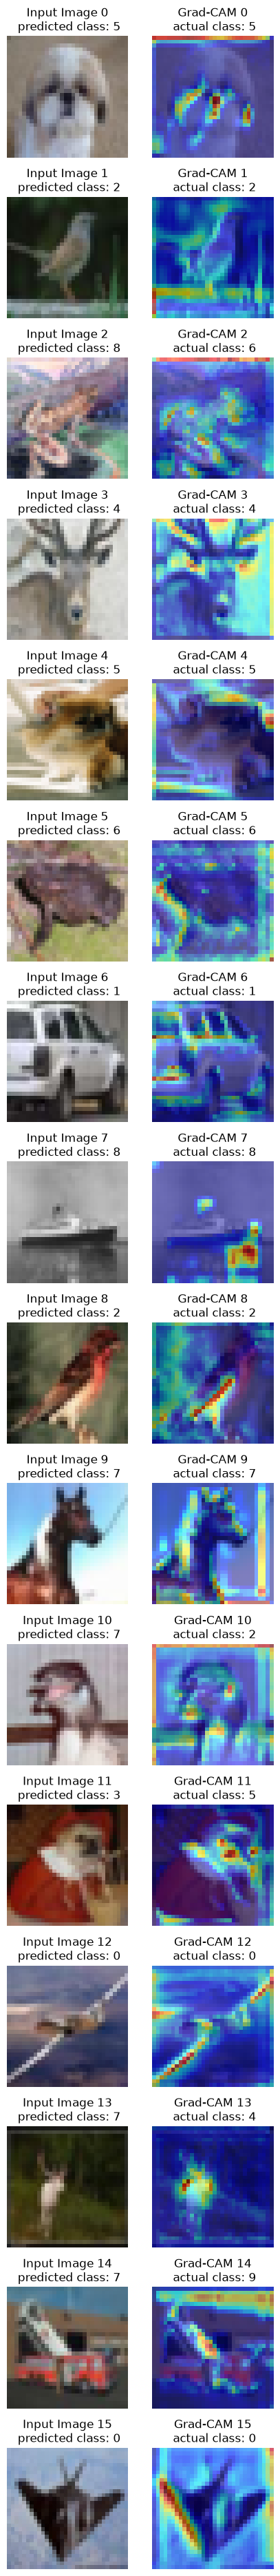

In [ ]:
# We have to specify the target we want to generate the CAM for.
def cam_for_batch(model: SimpleCNN, input_tensor: torch.Tensor, target: torch.Tensor):
    targets = [ClassifierOutputTarget(target[i].item()) for i in range(target.shape[0])]
    target_layers = [model.conv1, model.conv2]
    # Construct the CAM object once, and then re-use it on many images.
    with GradCAM(model=model, target_layers=target_layers) as cam:
        # You can also pass aug_smooth=True and eigen_smooth=True, to apply smoothing.
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        model_outputs = cam.outputs
    return grayscale_cam, model_outputs


from matplotlib import pyplot as plt

fig, axs = plt.subplots(
    input_tensor.shape[0], 2, figsize=(5, 3 * input_tensor.shape[0])
)
grayscale_cam, model_outputs = cam_for_batch(model, input_tensor, target)
for i in range(input_tensor.shape[0]):
    ax_a = axs[i, 0] if input_tensor.shape[0] > 1 else axs[0]
    ax_a.imshow(input_tensor[i].permute(1, 2, 0).cpu().numpy())
    ax_a.set_title(
        f"Input Image {i}\n target class: {target[i].item()}"
    )
    ax_a.axis("off")
    ax_b = axs[i, 1] if input_tensor.shape[0] > 1 else axs[1]
    ax_b.imshow(
        show_cam_on_image(
            input_tensor[i].permute(1, 2, 0).cpu().numpy(),
            grayscale_cam[i],
            use_rgb=True,
        )
    )
    ax_b.set_title(f"Grad-CAM {i}\n predicted class: {target[i].item()}")
    ax_b.axis("off")

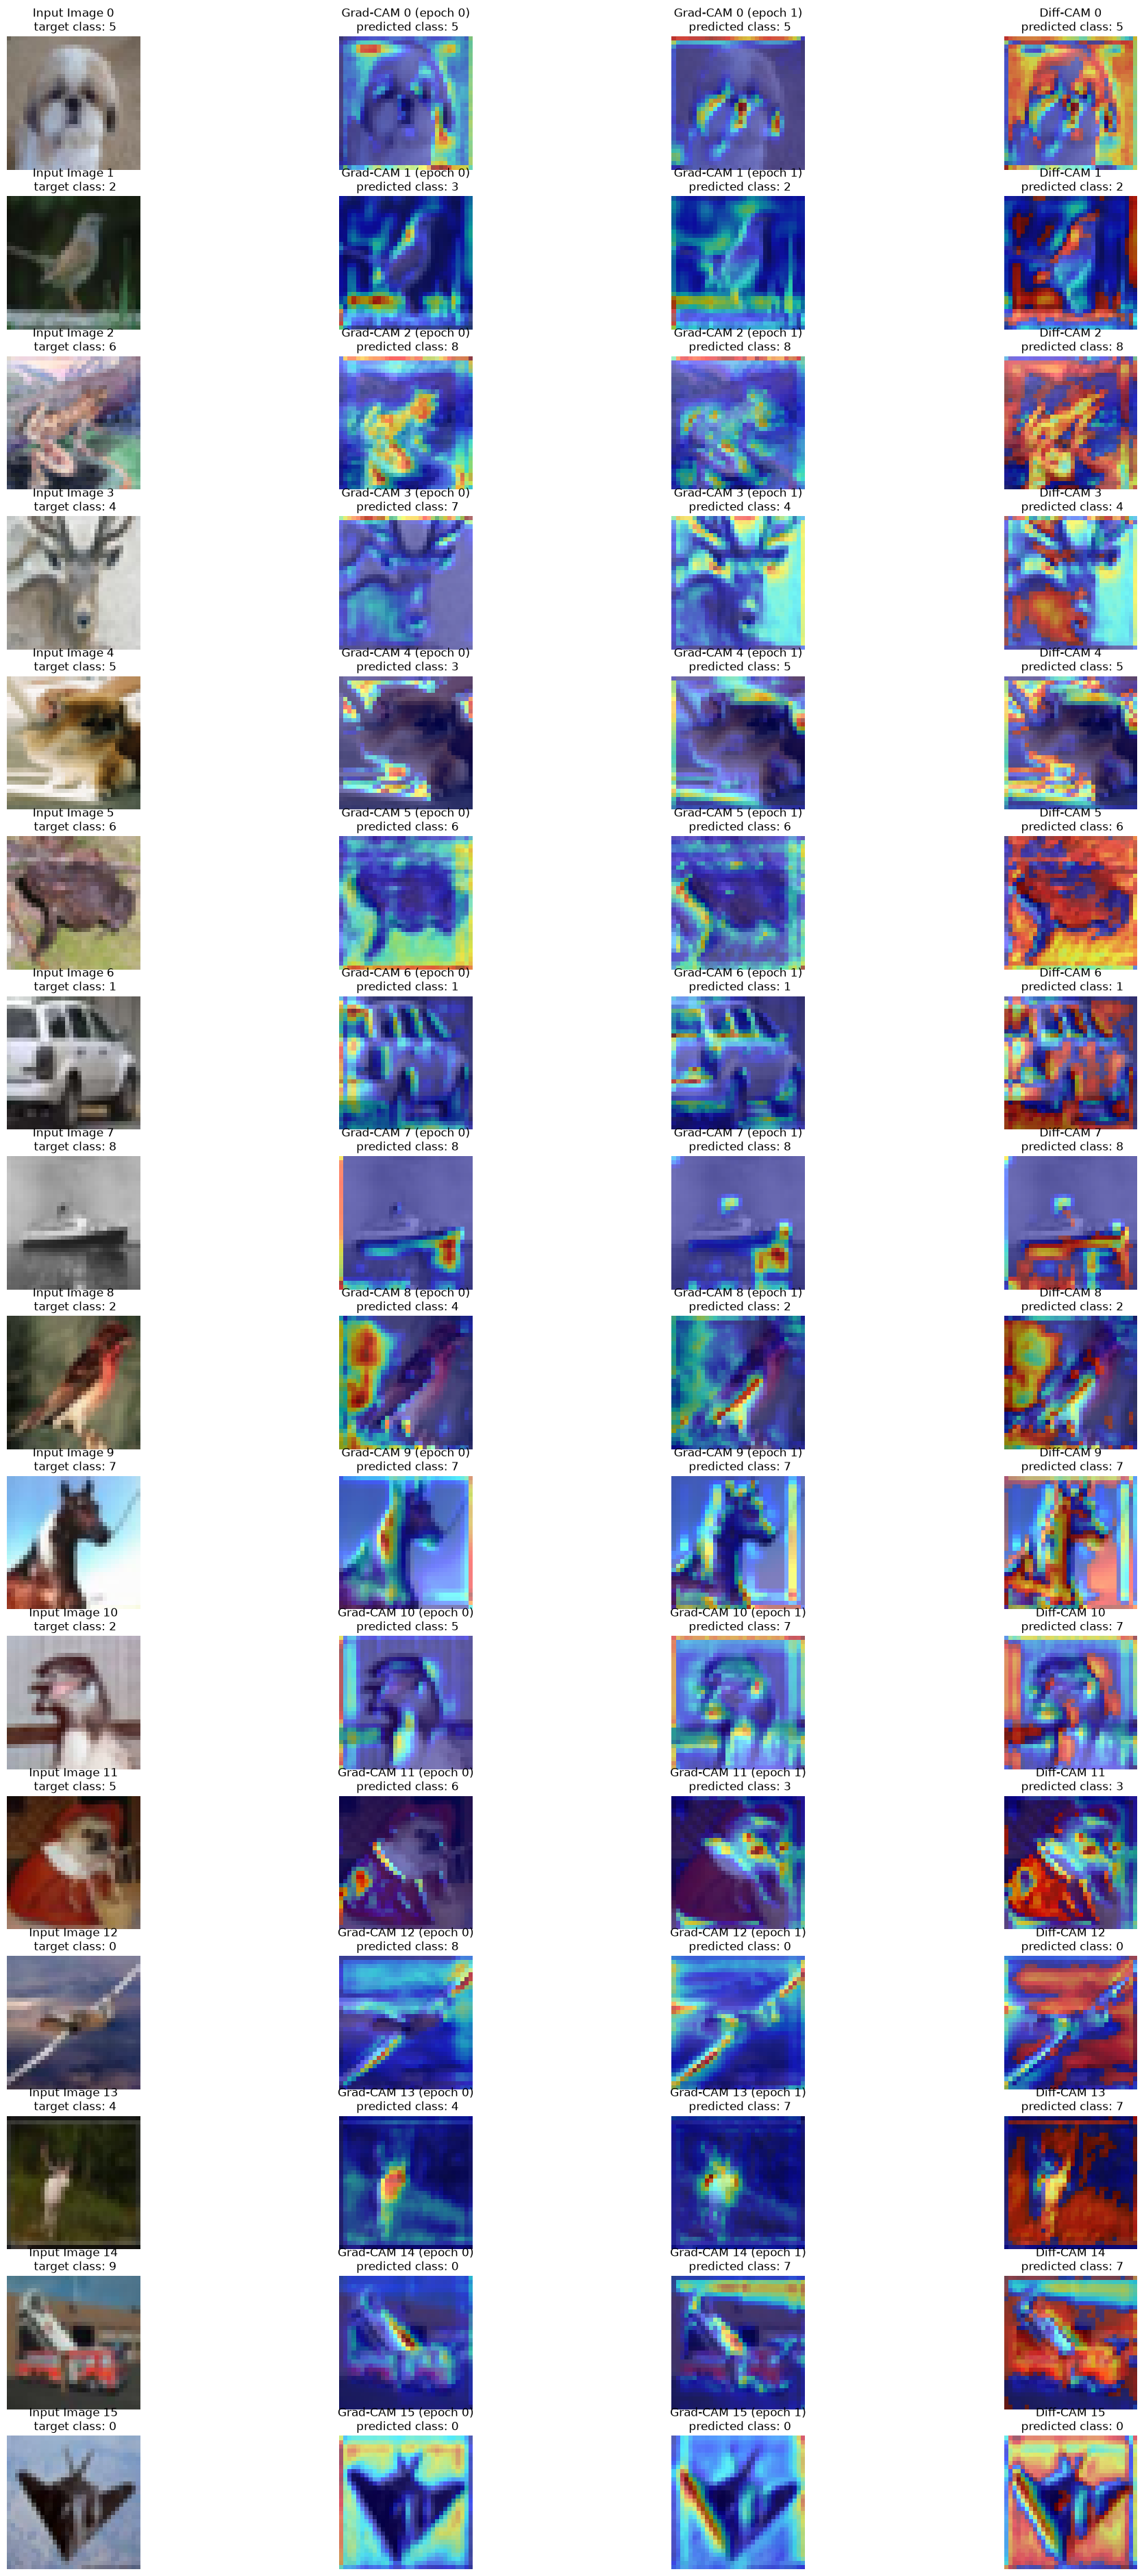

In [50]:
def load_model_state_dict(epoch: int, m_constructor=SimpleCNN):
    model = m_constructor()
    state_dict = torch.load(model_dir / f"model_epoch_{epoch}.pt", map_location=dev)
    model.load_state_dict(state_dict)
    return model


epoch_models = [load_model_state_dict(epoch) for epoch in range(epochs)]
# Differential CAM: last vs first epoch
models_cams = [epoch_models[0], epoch_models[-1]]
cams = []
outputs = []
for m in models_cams:
    grayscale_cam, model_outputs = cam_for_batch(m, input_tensor, target)
    cams.append(grayscale_cam)
    outputs.append(model_outputs)
fig, axs = plt.subplots(
    input_tensor.shape[0],
    4,
    figsize=(2 * (2 + len(epoch_models)), 3 * input_tensor.shape[0]),
)
for i in range(input_tensor.shape[0]):
    ax_a = axs[i, 0] if input_tensor.shape[0] > 1 else axs[0]
    ax_a.imshow(input_tensor[i].permute(1, 2, 0).cpu().numpy())
    ax_a.set_title(f"Input Image {i}\n target class: {target[i].item()}")
    ax_a.axis("off")
    for j, (model_cam, outputs_model) in enumerate(zip(cams, outputs)):
        ax_b = axs[i, j + 1] if input_tensor.shape[0] > 1 else axs[j + 1]
        ax_b.imshow(
            show_cam_on_image(
                input_tensor[i].permute(1, 2, 0).cpu().numpy(),
                model_cam[i],
                use_rgb=True,
            )
        )
        ax_b.set_title(
            f"Grad-CAM {i} (epoch {j})\n predicted class: {outputs_model[i].argmax().item()}"
        )
        ax_b.axis("off")
    diff_cam = cams[-1] - cams[0]
    ax_c = axs[i, -1] if input_tensor.shape[0] > 1 else axs[-1]
    ax_c.imshow(
        show_cam_on_image(
            input_tensor[i].permute(1, 2, 0).cpu().numpy(),
            diff_cam[i],
            use_rgb=True,
        )
    )
    ax_c.set_title(f"Diff-CAM {i}\n predicted class: {outputs[-1][i].argmax().item()}")
    ax_c.axis("off")


In [47]:
m

<All keys matched successfully>